In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
import mapclassify
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors
import matplotlib.patches as patches

In [2]:
gpd.__version__

'1.1.1'

In [3]:
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family']= "Verdana"

<Axes: >

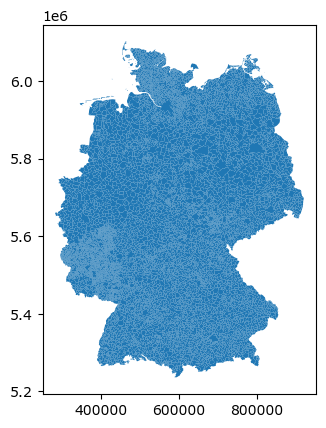

In [16]:
gemeinden = gpd.read_file('../geo/VG250_GEM_Zensus2022.zip').query("GF==4").set_index("ARS") # ohne (Hochsee)gewässer
gemeinden.plot()

In [17]:
# representative (inner) point for labelling
gemeinden['rPoint'] = gemeinden['geometry'].apply(lambda x: x.representative_point().coords[:])

In [18]:
gemeinden.head(3)

,OBJID,BEGINN,ADE,GF,BSG,AGS,SDV_ARS,GEN,BEZ,IBZ,...,SN_V2,SN_G,FK_S3,NUTS,ARS_0,AGS_0,WSK,DLM_ID,geometry,rPoint
ARS,,,,,,,,,,,,,,,,,,,,,
010010000000,DEBKGVG200000008,2021-12-02,6,4,1,01001000,010010000000,Flensburg,Stadt,60,...,00,000,R,DEF01,010010000000,01001000,2008-01-01,DEBKGDL20000E5MA,"POLYGON ((526513.753 6075133.412, 526547.941 6...","[(528440.5171787436, 6071278.827652828)]"
010020000000,DEBKGVG200000009,2021-11-30,6,4,1,01002000,010020000000,Kiel,Stadt,60,...,00,000,R,DEF02,010020000000,01002000,2006-01-01,DEBKGDL20000004J,"POLYGON ((575841.569 6032148.032, 575869.668 6...","[(573476.8189449809, 6022167.546686487)]"
010030000000,DEBKGVG20000000A,2021-06-24,6,4,1,01003000,010030000000,Lübeck,Stadt,60,...,00,000,R,DEF03,010030000000,01003000,2006-02-01,DEBKGDL20000DYMA,"POLYGON ((623056.151 5983746.445, 623191.574 5...","[(613547.449708947, 5971702.667253959)]"


In [19]:
# https://ergebnisse.zensus2022.de/datenbank/online/table/1000A-1018/
gem = pd.read_csv("1000A-1018_de_flat.zip", sep=";", 
                                        decimal=",", na_values=[".","-"],
                                        dtype={"1_variable_attribute_code":str})

In [20]:
religion = gem.query("time=='2022-05-15'").pivot(index="1_variable_attribute_code", columns=["2_variable_attribute_label"], values="value")

In [21]:
religion.rename(columns={"Evangelische Kirche (öffentlich-rechtlich)":"Evangelische Kirche",
                      "Römisch-katholische Kirche (öffentlich-rechtlich)":"Römisch-katholische Kirche"}, inplace=True)

In [22]:
religion["einfacheMehrheit"] = religion.idxmax(axis=1, numeric_only=True)

In [23]:
religion[religion.index!='DG'].describe()

2_variable_attribute_label,Evangelische Kirche,Römisch-katholische Kirche,"Sonstige, keine, ohne Angabe"
count,52.000000,52.000000,52.000000
mean,14.242308,56.938462,28.811538
std,7.895527,11.241697,5.624061
min,4.200000,29.700000,21.500000
25%,7.925000,49.900000,24.850000
50%,12.000000,59.900000,28.050000
75%,19.000000,65.450000,31.525000
max,37.500000,73.000000,46.000000


In [24]:
mapdata = gemeinden.join(religion[religion.index!='DG'], how="right")

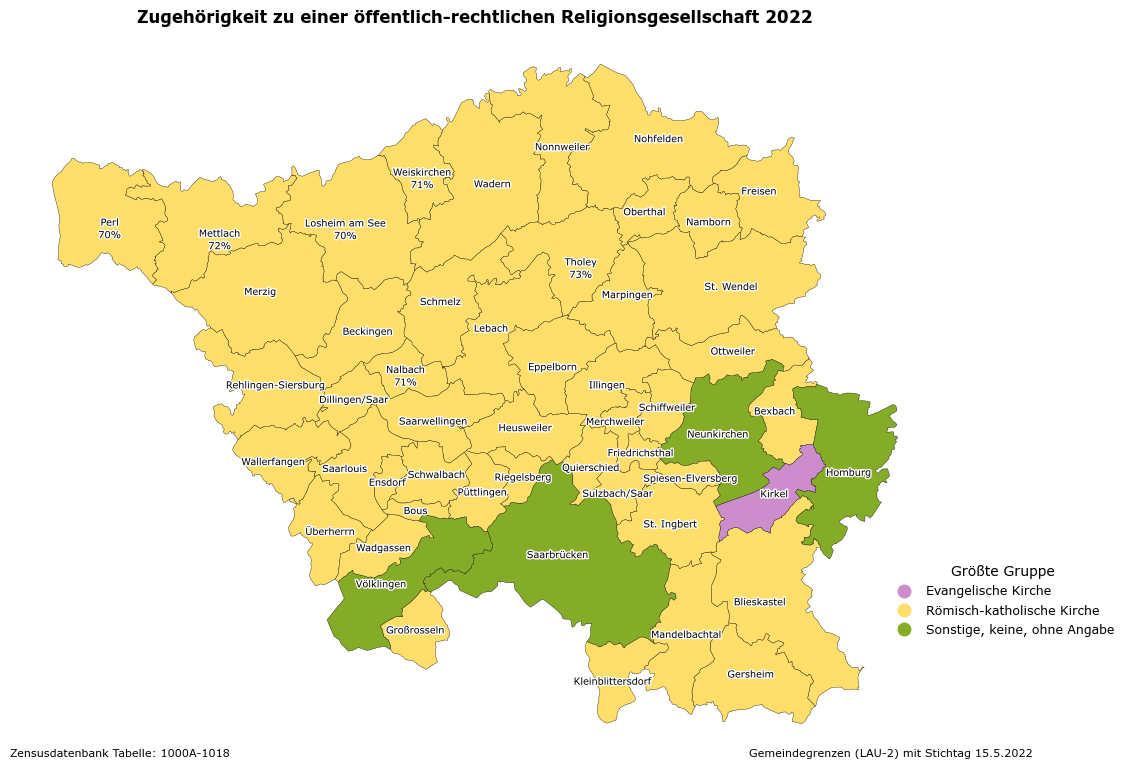

In [28]:
fig, ax = plt.subplots(1, figsize=(12, 10))
fig.set_facecolor("#fff")
ax.axis("off")

ax.set_title("Zugehörigkeit zu einer öffentlich-rechtlichen Religionsgesellschaft 2022", fontdict={"fontsize": 12, "fontweight" : "bold"})
ax.annotate("Zensusdatenbank Tabelle: 1000A-1018", xy=(0,0), xycoords='axes fraction', ha="left", fontsize= 8)
ax.annotate("Gemeindegrenzen (LAU-2) mit Stichtag 15.5.2022", xy=(1.1,0), xycoords='axes fraction', ha="right", fontsize= 8)

colors = ["#cd8dcd", "#ffde6a", "#84ac27"]
my_cmap = mcolors.ListedColormap(colors, name="my_cmap")

mapdata.plot(column="einfacheMehrheit", categorical=True, cmap = my_cmap,
                     #cmap="PuBu", 
                     #scheme="NaturalBreaks", k=6, # scheme="EqualInterval | NaturalBreaks"
                     #scheme='UserDefined', classification_kwds={'bins': [12,24,36,48,60,72]},
                     #missing_kwds = dict(color='#ccc', label='–'),
                     legend=True, legend_kwds={"frameon":False, "markerscale": 1, 
                                  "bbox_to_anchor":(1.2, 0.28), "fontsize": 9, "title":"Größte Gruppe"},
                     linewidth=0.25, ax=ax, edgecolor="#000")

for index, row in mapdata.iterrows():
    
        ax.annotate(row.GEN, row.rPoint[0], 
                    textcoords="offset points", xytext=(0,-1), ha="center", va="center",
                    fontsize=7, fontweight="normal", color="#000",
                    path_effects=[pe.withStroke(linewidth=2, foreground="#fff")])

        if row["Römisch-katholische Kirche"] > 70:

            ax.annotate('{:.0%}'.format(row["Römisch-katholische Kirche"]/100), row.rPoint[0], 
                        textcoords="offset points", xytext=(0,-10), ha="center", va="center",
                        fontsize=7, fontweight="normal", color="#000",
                        path_effects=[pe.withStroke(linewidth=2, foreground="#fff")])

plt.savefig('gem_karte_sl_religion.svg', bbox_inches='tight', pad_inches=0.15)  # , dpi=250  
plt.show()